In [1]:
import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)

import seaborn as sns
import matplotlib.pyplot as plt

import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/train.csv
/kaggle/input/description.md
/kaggle/input/sample_submission.csv.zip
/kaggle/input/test.csv.zip
/kaggle/input/train.csv.zip
/kaggle/input/test.csv
/kaggle/input/sample_submission.csv
/kaggle/input/playground-series-s3e18/train.csv
/kaggle/input/playground-series-s3e18/description.md
/kaggle/input/playground-series-s3e18/sample_submission.csv.zip
/kaggle/input/playground-series-s3e18/test.csv.zip
/kaggle/input/playground-series-s3e18/train.csv.zip
/kaggle/input/playground-series-s3e18/test.csv
/kaggle/input/playground-series-s3e18/sample_submission.csv


In [2]:
df_train = pd.read_csv("/kaggle/input/playground-series-s3e18/train.csv")
df_test = pd.read_csv("/kaggle/input/playground-series-s3e18/test.csv")
sample_submission = pd.read_csv(
    "/kaggle/input/playground-series-s3e18/sample_submission.csv"
)


In [3]:
df_train.head()


,id,BertzCT,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3v,Chi4n,EState_VSA1,...,SlogP_VSA3,VSA_EState9,fr_COO,fr_COO2,EC1,EC2,EC3,EC4,EC5,EC6
0,3305,212.928441,6.270857,3.431698,4.045502,1.811731,2.272429,1.619489,0.828835,7.822697,...,13.825658,36.819857,0,0,1,1,0,1,0,0
1,8217,221.694355,4.060660,3.548618,3.548618,2.499652,2.499652,1.607504,0.883813,17.980451,...,9.589074,39.833333,2,2,1,0,0,1,0,0
2,12616,159.130752,4.414719,2.801636,2.801636,2.676274,2.676274,1.204209,0.361282,12.011146,...,11.215359,33.500000,1,1,1,1,0,0,0,0
3,10153,1239.282494,16.098662,10.151117,10.151117,11.008637,11.008637,7.914542,3.408511,5.969305,...,9.589074,73.500000,1,1,1,1,0,0,0,0
4,9564,574.170559,8.417121,5.143525,5.143525,3.478542,3.478542,2.264463,2.087653,5.969305,...,4.794537,39.166667,1,1,1,0,0,1,0,0


findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Fon

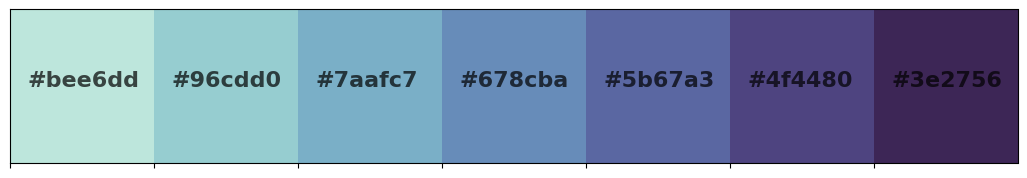

In [4]:
my_palette = sns.cubehelix_palette(
    n_colors=7, start=0.46, rot=-0.45, dark=0.2, hue=0.95
)
sns.palplot(my_palette)
plt.gcf().set_size_inches(13, 2)

for idx, values in enumerate(my_palette.as_hex()):
    plt.text(
        idx - 0.375,
        0,
        my_palette.as_hex()[idx],
        {"font": "Courier New", "size": 16, "weight": "bold", "color": "black"},
        alpha=0.7,
    )
plt.gcf().set_facecolor("white")
plt.show()


In [5]:
df_train.describe().T


,count,mean,std,min,25%,50%,75%,max
id,13354.0,7430.046054,4280.726674,0.000000,3725.250000,7424.500000,11138.750000,14837.000000
BertzCT,13354.0,515.344063,541.590240,0.000000,149.874524,292.455280,652.281490,4069.959780
Chi1,13354.0,9.135106,6.811711,0.000000,4.680739,6.494089,11.170340,69.551167
Chi1n,13354.0,5.854336,4.641652,0.000000,2.854294,4.059093,7.486482,50.174588
Chi1v,13354.0,6.741385,5.859587,0.000000,2.932842,4.392859,8.527859,53.431954
Chi2n,13354.0,4.434309,3.759906,0.000000,1.949719,2.970427,5.788793,32.195368
Chi2v,13354.0,5.251854,4.914257,0.000000,2.037238,3.261677,6.621896,34.579313
Chi3v,13354.0,3.416554,3.425819,0.000000,1.162568,1.951087,4.502070,22.589276
Chi4n,13354.0,1.772391,1.860338,0.000000,0.508512,1.077096,2.540348,16.072810
EState_VSA1,13354.0,29.207586,31.755738,0.000000,5.969305,17.353601,44.876559,363.705954


In [6]:
df_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13354 entries, 0 to 13353
Data columns (total 38 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 13354 non-null  int64  
 1   BertzCT            13354 non-null  float64
 2   Chi1               13354 non-null  float64
 3   Chi1n              13354 non-null  float64
 4   Chi1v              13354 non-null  float64
 5   Chi2n              13354 non-null  float64
 6   Chi2v              13354 non-null  float64
 7   Chi3v              13354 non-null  float64
 8   Chi4n              13354 non-null  float64
 9   EState_VSA1        13354 non-null  float64
 10  EState_VSA2        13354 non-null  float64
 11  ExactMolWt         13354 non-null  float64
 12  FpDensityMorgan1   13354 non-null  float64
 13  FpDensityMorgan2   13354 non-null  float64
 14  FpDensityMorgan3   13354 non-null  float64
 15  HallKierAlpha      13354 non-null  float64
 16  HeavyAtomMolWt     133

In [7]:
df_train[["MaxAbsEStateIndex", "MinEStateIndex"]]


,MaxAbsEStateIndex,MinEStateIndex
0,10.893972,-4.947221
1,9.226852,-1.165509
2,10.636065,-1.500880
3,11.526326,-1.439086
4,10.484861,-0.985000
...,...,...
13349,10.724019,-0.355278
13350,10.037773,-1.004630
13351,10.249692,-1.006481
13352,10.101852,-1.420185


In [8]:
df_train.drop("id", axis=1, inplace=True)
df_test.drop("id", axis=1, inplace=True)


In [9]:
target_col1 = "EC1"
target_col2 = "EC2"
num_cols = [
    "BertzCT",
    "Chi1",
    "Chi1n",
    "Chi1v",
    "Chi2n",
    "Chi2v",
    "Chi3v",
    "Chi4n",
    "EState_VSA1",
    "EState_VSA2",
    "ExactMolWt",
    "FpDensityMorgan1",
    "FpDensityMorgan2",
    "FpDensityMorgan3",
    "HallKierAlpha",
    "HeavyAtomMolWt",
    "Kappa3",
    "MaxAbsEStateIndex",
    "MinEStateIndex",
    "NumHeteroatoms",
    "PEOE_VSA10",
    "PEOE_VSA14",
    "PEOE_VSA6",
    "PEOE_VSA7",
    "PEOE_VSA8",
    "SMR_VSA10",
    "SMR_VSA5",
    "SlogP_VSA3",
    "VSA_EState9",
]
binary_cols = ["EC1", "EC2", "EC3", "EC4", "EC5", "EC6"]
cat_cols = df_test.select_dtypes(include=["object"]).columns.tolist()

print(f"[INFO] Shapes:" f"\n train: {df_train.shape}" f"\n test: {df_test.shape}\n")

print(
    f"[INFO] Any missing values:"
    f"\n train: {df_train.isna().any().any()}"
    f"\n test: {df_test.isna().any().any()}"
)


[INFO] Shapes:
 train: (13354, 37)
 test: (1484, 31)

[INFO] Any missing values:
 train: False
 test: False


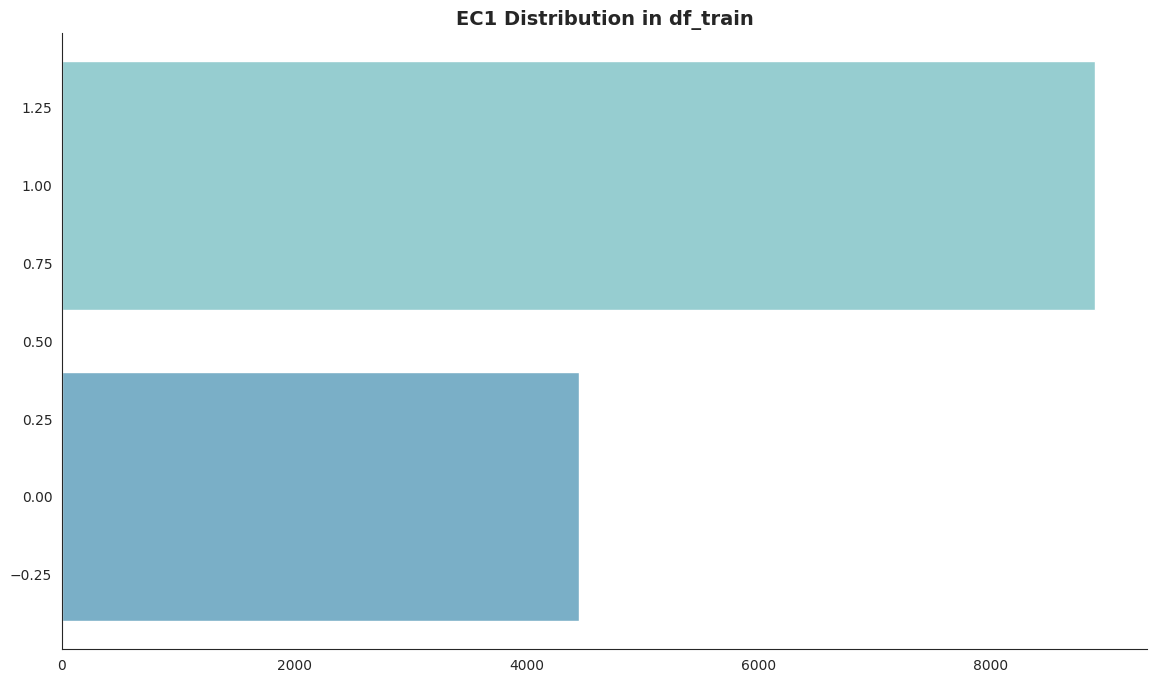

In [10]:
plt.figure(figsize=(14, 8))
sns.set_style("white")
colors = my_palette
plt.barh(
    df_train[target_col1].value_counts().index,
    df_train[target_col1].value_counts(),
    color=colors[1:3],
)
plt.title("EC1 Distribution in df_train", fontsize=14, fontweight="bold")
sns.despine()
plt.show()


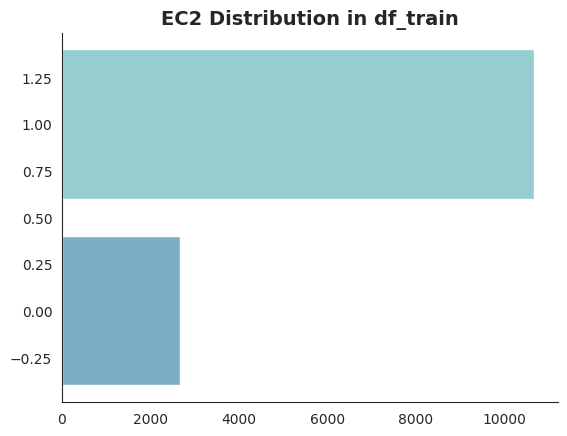

In [11]:
plt.barh(
    df_train[target_col2].value_counts().index,
    df_train[target_col2].value_counts(),
    color=colors[1:3],
)
plt.title("EC2 Distribution in df_train", fontsize=14, fontweight="bold")
sns.despine()
plt.show()


In [12]:
# Apply Yeo‑Johnson power transform to numeric columns only
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="yeo-johnson", standardize=True)

df_train[num_cols] = pt.fit_transform(df_train[num_cols])
df_test[num_cols] = pt.transform(df_test[num_cols])




In [13]:
def out_iqr(df):
    columns = df.columns
    iqrs, lower_out, upper_out = [], [], []
    for column in columns:
        q25, q75 = np.quantile(df[column], 0.25), np.quantile(df[column], 0.75)
        iqr = q75 - q25
        cut_off = iqr * 1.5
        lower, upper = q25 - cut_off, q75 + cut_off
        df1 = df[df[column] > upper].shape[0]
        df2 = df[df[column] < lower].shape[0]
        iqrs.append(iqr)
        upper_out.append(df1)
        lower_out.append(df2)
    return pd.DataFrame(
        data={
            "columns": df.columns,
            "iqr": iqrs,
            "lower_outliers": lower_out,
            "upper_outliers": upper_out,
        }
    ).style.background_gradient(axis=0, cmap="Greens")




In [14]:
out_iqr(df_train)


,columns,iqr,lower_outliers,upper_outliers
0,BertzCT,1.321586,181,10
1,Chi1,1.290858,149,4
2,Chi1n,1.311414,145,4
3,Chi1v,1.355721,136,1
4,Chi2n,1.349590,0,1
5,Chi2v,1.356701,0,0
6,Chi3v,1.392904,0,0
7,Chi4n,1.527379,0,0
8,EState_VSA1,1.388473,0,2
9,EState_VSA2,1.874473,0,0


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

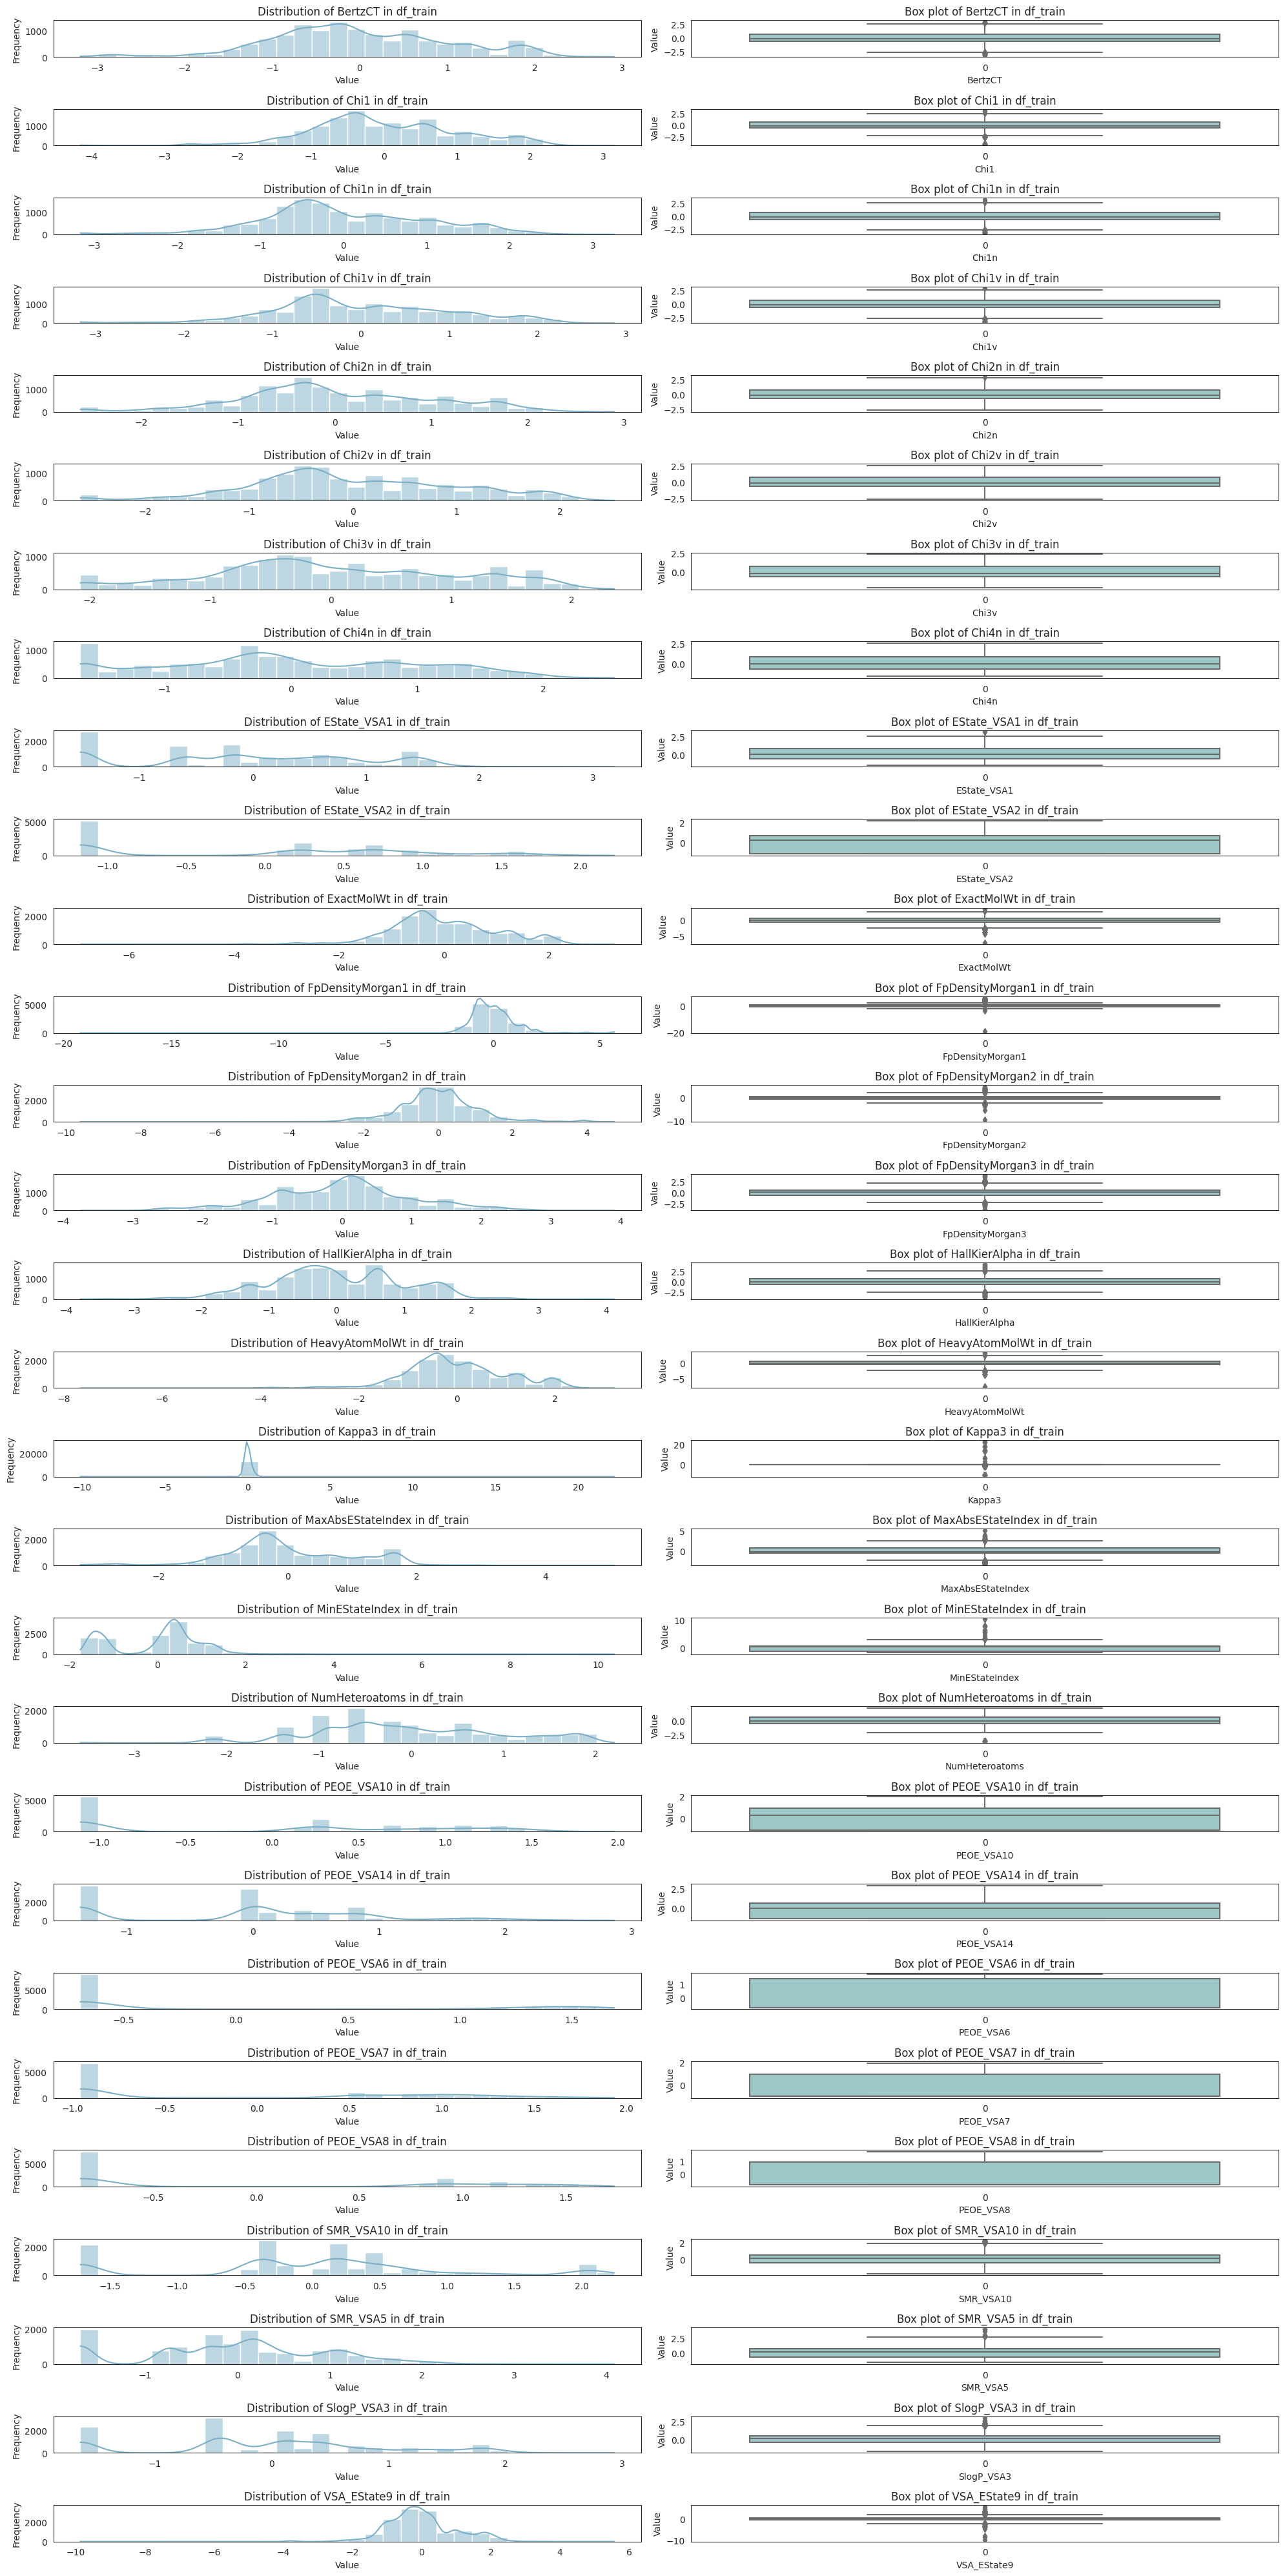

In [15]:
numerical_columns = num_cols
fig, axes = plt.subplots(len(numerical_columns), 2, figsize=(20, 40))
for i, column in enumerate(numerical_columns):
    sns.histplot(
        df_train[column], bins=30, kde=True, ax=axes[i, 0], color=my_palette[2]
    )
    axes[i, 0].set_title(f"Distribution of {column} in df_train")
    axes[i, 0].set_xlabel("Value")
    axes[i, 0].set_ylabel("Frequency")
    sns.boxplot(df_train[column], ax=axes[i, 1], color=my_palette[1])
    axes[i, 1].set_title(f"Box plot of {column} in df_train")
    axes[i, 1].set_xlabel(column)
    axes[i, 1].set_ylabel("Value")
plt.tight_layout()
plt.show()


In [16]:
# Train lightweight GradientBoosting models for EC1 and EC2 and create submission
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score

X = df_train[num_cols]
y_ec1 = df_train["EC1"]
y_ec2 = df_train["EC2"]

# Model for EC1
model_ec1 = GradientBoostingClassifier(random_state=42)
model_ec1.fit(X, y_ec1)

# Model for EC2
model_ec2 = GradientBoostingClassifier(random_state=42)
model_ec2.fit(X, y_ec2)

# Predict probabilities for the positive class
X_test = df_test[num_cols]
pred_ec1 = model_ec1.predict_proba(X_test)[:, 1]
pred_ec2 = model_ec2.predict_proba(X_test)[:, 1]

# Prepare submission
submission = pd.DataFrame(
    {
        "id": pd.read_csv("/kaggle/input/playground-series-s3e18/test.csv")["id"],
        "EC1": pred_ec1,
        "EC2": pred_ec2,
    }
)

submission.to_csv("submission.csv", index=False)
print("Submission file written to submission.csv")
print(submission.head())


Submission file written to submission.csv
      id       EC1       EC2
0   1377  0.748778  0.782860
1   5485  0.694233  0.773921
2   8753  0.464185  0.858847
3  10746  0.662568  0.747866
4   7554  0.471210  0.845648


In [17]:
# (optional) Evaluate on a quick train/validation split to sanity‑check performance
from sklearn.model_selection import train_test_split

X_tr, X_val, y1_tr, y1_val = train_test_split(
    X, y_ec1, test_size=0.2, random_state=42, stratify=y_ec1
)
model_tmp = GradientBoostingClassifier(random_state=42)
model_tmp.fit(X_tr, y1_tr)
val_pred = model_tmp.predict_proba(X_val)[:, 1]
print("Validation ROC‑AUC for EC1:", roc_auc_score(y1_val, val_pred))

Validation ROC‑AUC for EC1: 0.7021649075019861
